#Part 4 - Embeddings and similarity
### to understand how sentence embeddings capture meaning across different topics.


Importing libraries

In [1]:
!pip install sentence-transformers
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sentences = [
    # Cricket
    "The batsman hit a magnificent six over mid-wicket",
    "India needs 20 runs off the last two overs to win the match",
    "The fast bowler swung the ball late and clean-bowled the opener",
    # Cooking
    "Saute the onions in olive oil until they turn golden brown",
    "Always let the dough rest for at least one hour before baking",
    "Season the grilled chicken with cumin, paprika, and fresh lemon juice",
    # Cybersecurity
    "The hacker exploited a zero-day vulnerability to breach the firewall",
    "Multi-factor authentication significantly reduces the risk of account takeover",
    "Encrypting data at rest protects sensitive information from unauthorised access",
    "A phishing email tricked the employee into revealing their login credentials",
]

In [4]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)
print("Embedding shape :", embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding shape : (10, 384)


In [5]:
similarity_matrix = cosine_similarity(embeddings)
df = pd.DataFrame(similarity_matrix, index = sentences,columns = sentences)
df

,The batsman hit a magnificent six over mid-wicket,India needs 20 runs off the last two overs to win the match,The fast bowler swung the ball late and clean-bowled the opener,Saute the onions in olive oil until they turn golden brown,Always let the dough rest for at least one hour before baking,"Season the grilled chicken with cumin, paprika, and fresh lemon juice",The hacker exploited a zero-day vulnerability to breach the firewall,Multi-factor authentication significantly reduces the risk of account takeover,Encrypting data at rest protects sensitive information from unauthorised access,A phishing email tricked the employee into revealing their login credentials
The batsman hit a magnificent six over mid-wicket,1.000000,0.446684,0.536554,0.044823,0.021285,0.085045,0.083949,0.030178,-0.020389,0.032636
India needs 20 runs off the last two overs to win the match,0.446684,1.000000,0.354720,0.113086,0.076688,0.052931,0.076117,0.017905,-0.007346,-0.037850
The fast bowler swung the ball late and clean-bowled the opener,0.536554,0.354720,1.000000,0.105988,0.091864,0.095475,0.186281,0.000966,-0.024240,0.046275
Saute the onions in olive oil until they turn golden brown,0.044823,0.113086,0.105988,1.000000,0.237527,0.357771,-0.023312,-0.148846,0.068296,0.096947
Always let the dough rest for at least one hour before baking,0.021285,0.076688,0.091864,0.237527,1.000000,0.030028,0.021317,-0.001994,0.097438,0.106885
"Season the grilled chicken with cumin, paprika, and fresh lemon juice",0.085045,0.052931,0.095475,0.357771,0.030028,1.000000,-0.047798,-0.056247,-0.058546,-0.046413
The hacker exploited a zero-day vulnerability to breach the firewall,0.083949,0.076117,0.186281,-0.023312,0.021317,-0.047798,1.000000,0.165398,0.106693,0.285659
Multi-factor authentication significantly reduces the risk of account takeover,0.030178,0.017905,0.000966,-0.148846,-0.001994,-0.056247,0.165398,1.000000,0.187405,0.380134
Encrypting data at rest protects sensitive information from unauthorised access,-0.020389,-0.007346,-0.024240,0.068296,0.097438,-0.058546,0.106693,0.187405,1.000000,0.208143
A phishing email tricked the employee into revealing their login credentials,0.032636,-0.037850,0.046275,0.096947,0.106885,-0.046413,0.285659,0.380134,0.208143,1.000000


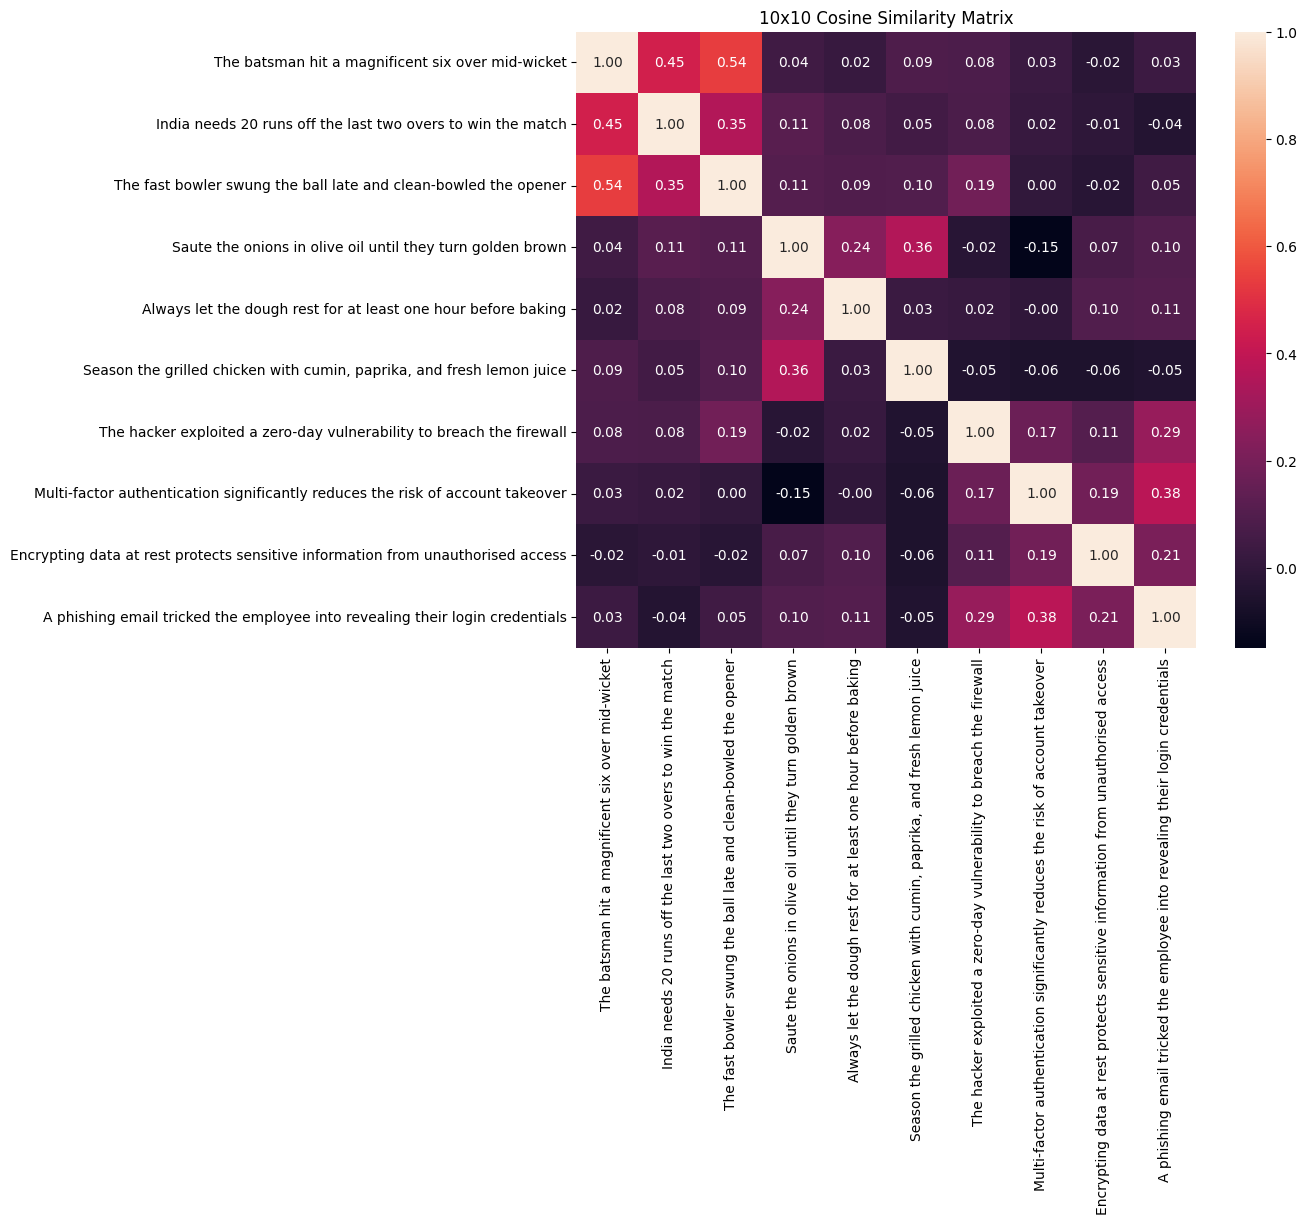

In [6]:
plt.figure(figsize=(10, 8))
sns.heatmap(df, annot=True,fmt =".2f")
plt.title("10x10 Cosine Similarity Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [7]:
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

In [8]:
similarities = cosine_similarity(query_embedding, embeddings)[0]
top_indices = np.argsort(similarities)[-2:][::-1]

print("Query:",query)
print("\n Top 2 similar sentences:\n")

for i in top_indices:
  print("Sentence:",sentences[i])
  print("Similarity score:", round(similarities[i],4))
  print()

Query: The bowler took three wickets in one over

 Top 2 similar sentences:

Sentence: The fast bowler swung the ball late and clean-bowled the opener
Similarity score: 0.6838

Sentence: The batsman hit a magnificent six over mid-wicket
Similarity score: 0.6364



Insights:-

Sentences from the same topic have higher average similarity compared to sentences from different topics.

This confirms that embeddings group semantically related content together even when the wording is different.
